# Transit Search & Detection Table

BLS period search on the 8 PSLS-simulated planetary systems from the HZ target selection grid.  
Recovered periods are compared to injected values to produce a reproducible detection table.

**Systems:** 3 stellar hosts (K, G, F) × hot inner / HZ / cold outer / adversarial orbit cases  
**Search method:** Box Least Squares (Astropy) with harmonic alias refinement  
**Detection criterion:** coherent SNR ≥ 7 AND period_error < 5% AND BLS peak SNR ≥ 5

## Habitable Zone Physics

For each recovered planet candidate we compute three quantities from first principles:

### 1. Stellar Luminosity
$$\frac{L_*}{L_\odot} = \left(\frac{R_*}{R_\odot}\right)^2 \left(\frac{T_*}{T_\odot}\right)^4$$

### 2. Incident Stellar Flux (Earth units)
$$S = \frac{L_*/L_\odot}{(a/\mathrm{AU})^2}$$

Earth receives $S = 1$ by definition. Conservative HZ bounds (Kopparapu et al.): $0.95 \leq S \leq 1.37$.

### 3. Planetary Equilibrium Temperature
$$T_{\mathrm{eq}} = T_* \sqrt{\frac{R_*}{2a}}\,(1-A)^{1/4}$$

We use bond albedo $A = 0.3$ (Earth-like). The **zero-albedo form** ($A = 0$) gives a strict upper bound:
$$T_{\mathrm{eq},A=0} = T_* \sqrt{\frac{R_*}{2a}}$$

In [ ]:
# Cell 1 — Imports & configuration (all imports consolidated here)
import sys
import os
import glob
import math
import pickle
import yaml

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import jinja2  # noqa: F401  (DataFrame.style HTML tables)

from astropy.timeseries import BoxLeastSquares
from scipy.stats import spearmanr, kendalltau
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_curve, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay,
    precision_score, recall_score, f1_score,
    r2_score, mean_absolute_error,
)

sys.path.insert(0, os.path.abspath('../'))  # make local modules importable BEFORE local imports
from habitable_zone_pipeline import (
    run_bls_recovery_with_refinement,
    stellar_luminosity_solar,
    incident_flux_earth_units,
    equilibrium_temperature_from_au,
    habitable_zone_flags,
    habitability_rank_score,
    phase_fold_lightcurve,
    load_cnn_models,
)
from transit_helpers import (
    load_systems_from_yaml,
    load_psls_dat,
    detrend_flux,
    transit_depth_ppm,
    verdict,
    BLS_STRIDE,
    plot_bls_diagnostic,
)
from ml_pipeline import (
    FEATURE_COLS_A,
    FEATURE_COLS_B,
    FEATURE_COLS_B_MLP,
    predict_transit_prob,
    predict_rank_score,
    predict_transit_prob_cnn,
    predict_rank_score_mlp,
    load_models,
)

OUTPUTS_DIR    = os.path.abspath('sim_systems/outputs')
BASELINE_DAYS  = 270.0*3   # 3 PLATO quarter block

SNR_THRESHOLD  = 7.0
PERIOD_TOL_PCT = 5.0

VERDICT_COLORS = {
    'Promising':     '#2ecc71',
    'Marginal':      '#f39c12',
    'Non-promising': '#e74c3c',
}


In [ ]:
# Cache configuration — set FORCE_RERUN=True to bypass and recompute

CACHE_DIR   = "sim_systems/cache"
FORCE_RERUN = False

os.makedirs(CACHE_DIR, exist_ok=True)
print(f"Cache dir : {os.path.abspath(CACHE_DIR)}")
print(f"FORCE_RERUN={FORCE_RERUN}")

Cache dir : /home/phuy2808/Astrophysis/MASS/sem_2/Astrobio/sim_systems/cache
FORCE_RERUN=False


In [ ]:
# Load ground truth from YAML configs

SYSTEMS = load_systems_from_yaml('sim_systems')

print(f'{len(SYSTEMS)} systems loaded from YAML')
for name, s in SYSTEMS.items():
    print(f'  {name:25s}  P={s["p_inj"]:5.0f}d  {s["star_type"]:14s}  {s["science_case"]}')

12 systems loaded from YAML
  A1_K_hot                   P=   12d  K-dwarf         Hot inner control
  A2_K_hz                    P=   45d  K-dwarf         HZ target
  B1_G_hot                   P=   15d  G-dwarf         Hot inner control
  B2_G_hz                    P=  365d  G-dwarf         HZ target (Earth analog)
  B3_G_cold                  P=  730d  G-dwarf         Cold outer control
  C1_F_hot                   P=   20d  F-dwarf         Hot inner control
  C2_F_hz                    P=  500d  F-dwarf         HZ target
  C3_F_adversarial           P=  500d  F-dwarf         Adversarial (noisy)
  D1_K_hz_promising          P=  119d  K-dwarf         HZ promising (super-Earth)
  D2_K_hz_promising2         P=   77d  Late K-dwarf    HZ promising (super-Earth)
  D3_G_hot_control           P=    8d  G-dwarf         Hot inner control
  D4_G_cold_control          P=  500d  G-dwarf         Cold outer control


#  Physics + BLS Core 
Transit recovery (BLS) and the transparent, physically-motivated habitability
score `H = H_HZ + 0.2·H_Rp + 0.15·H_host + 0.15·H_det + 0.1·H_stab`.


In [ ]:
# BLS search loop — cached
# Pipeline: load → downsample → detrend (running median, 1d window) → BLS
# SNR = depth_ppm * sqrt(n_transits) / noise_ppm  (coherent transit stack SNR)

DETREND_WIN_D   = 1.0

_cache_bls  = os.path.join(CACHE_DIR, "bls_results_store.pkl")
_cache_lc   = os.path.join(CACHE_DIR, "lc_store.pkl")
_cache_rows = os.path.join(CACHE_DIR, "rows.pkl")

_cache_valid = (
    not FORCE_RERUN
    and all(os.path.exists(f) for f in [_cache_bls, _cache_lc, _cache_rows])
)

if _cache_valid:
    with open(_cache_bls,  "rb") as f: bls_results_store = pickle.load(f)
    with open(_cache_lc,   "rb") as f: lc_store          = pickle.load(f)
    with open(_cache_rows, "rb") as f: rows               = pickle.load(f)
    print(f"[cache] Loaded BLS results for {len(rows)} systems from {CACHE_DIR}")
else:
    rows = []
    bls_results_store = {}
    lc_store = {}

    for config, truth in SYSTEMS.items():
        pattern = os.path.join(OUTPUTS_DIR, config, '*.dat')
        matches = glob.glob(pattern)
        if not matches:
            print(f'  WARNING: no .dat found for {config}, skipping')
            continue
        dat_path = matches[0]
        print(f'Loading {config} ... ', end='', flush=True)

        time_days, flux_raw = load_psls_dat(dat_path)
        lc_store[config] = (time_days, flux_raw)
        print(f'{len(time_days):,} pts', end='', flush=True)

        flux_det = detrend_flux(time_days, flux_raw, window_days=DETREND_WIN_D)
        noise_ppm = np.std((flux_det - 1.0) * 1e6)
        print(f'  detrended noise={noise_ppm:.1f} ppm', flush=True)

        p_inj = truth['p_inj']
        p_min = max(0.5 * p_inj, 1.0)
        p_max = min(1.5 * p_inj, 0.48 * BASELINE_DAYS)

        if p_min >= p_max:
            print(f'  P={p_inj}d > 0.48×baseline — period longer than window, no BLS')
            rec = {
                'period_recovered_days':   float('nan'),
                'duration_recovered_days': 0.0,
                'bls_peak_snr':            0.0,
                'depth_snr':               0.0,
                'depth_frac':              0.0,
                'period_grid_days':        np.array([]),
                'snr_grid':                np.array([]),
            }
        else:
            rec = run_bls_recovery_with_refinement(
                time_days, flux_det, p_min, p_max, n_periods=1500
            )
        bls_results_store[config] = rec

        p_rec = rec['period_recovered_days']
        p_err = abs(p_rec - p_inj) / p_inj * 100 if not math.isnan(p_rec) else float('nan')
        n_tr  = max(int(BASELINE_DAYS / p_inj), 0)
        depth = transit_depth_ppm(truth['rp_re'], truth['rstar'])

        if n_tr > 0 and noise_ppm > 0:
            snr = depth * math.sqrt(n_tr) / noise_ppm
        else:
            snr = 0.0

        detected = (
            snr >= SNR_THRESHOLD
            and p_err <= PERIOD_TOL_PCT
        )

        lum     = stellar_luminosity_solar(truth['rstar'], truth['teff'])
        s_earth = incident_flux_earth_units(lum, truth['a_au'])
        teq     = equilibrium_temperature_from_au(truth['teff'], truth['rstar'], truth['a_au'])
        flags   = habitable_zone_flags(s_earth, teq)
        scores  = habitability_rank_score(s_earth, truth['rp_re'], truth['teff'], max(snr, rec["bls_peak_snr"]))

        v = verdict(detected, flags['in_habitable_zone_flux'], flags.get('near_habitable_zone_loose', False))

        if v == "Promising":
            plot_bls_diagnostic(config, time_days, flux_det, rec, truth=truth)


        rows.append({
            'config':                     config,
            'science_case':               truth['science_case'],
            'star_type':                  truth['star_type'],
            'P_injected_d':               p_inj,
            'P_recovered_d':              round(p_rec, 2) if not math.isnan(p_rec) else float('nan'),
            'period_error_pct':           round(p_err, 2) if not math.isnan(p_err) else float('nan'),
            'n_transits_expected':        n_tr,
            'depth_ppm':                  round(depth, 1),
            'bls_peak_snr':               round(rec["bls_peak_snr"], 4),
            'depth_snr':                  round(snr, 2),
            'detected':                   detected,
            'S_earth':                    round(s_earth, 4),
            'Teq_K':                      round(teq, 1),
            'in_habitable_zone_flux':     flags['in_habitable_zone_flux'],
            'in_habitable_zone_teq_band': flags['in_habitable_zone_teq_band'],
            'rank_score':                 round(scores['rank_score'], 4),
            'verdict':                    v,
        })
        print(f'  SNR={snr:.2f}  P_rec={p_rec:.1f}d  err={p_err:.1f}%  detected={detected}  → {v}')

    print(f'\nDone — {len(rows)} systems')

    with open(_cache_bls,  "wb") as f: pickle.dump(bls_results_store, f)
    with open(_cache_lc,   "wb") as f: pickle.dump(lc_store, f)
    with open(_cache_rows, "wb") as f: pickle.dump(rows, f)
    print(f"[cache] Saved BLS results → {CACHE_DIR}")

[cache] Loaded BLS results for 12 systems from sim_systems/cache


Plotting 2 Promising system(s): ['D1_K_hz_promising', 'D2_K_hz_promising2']


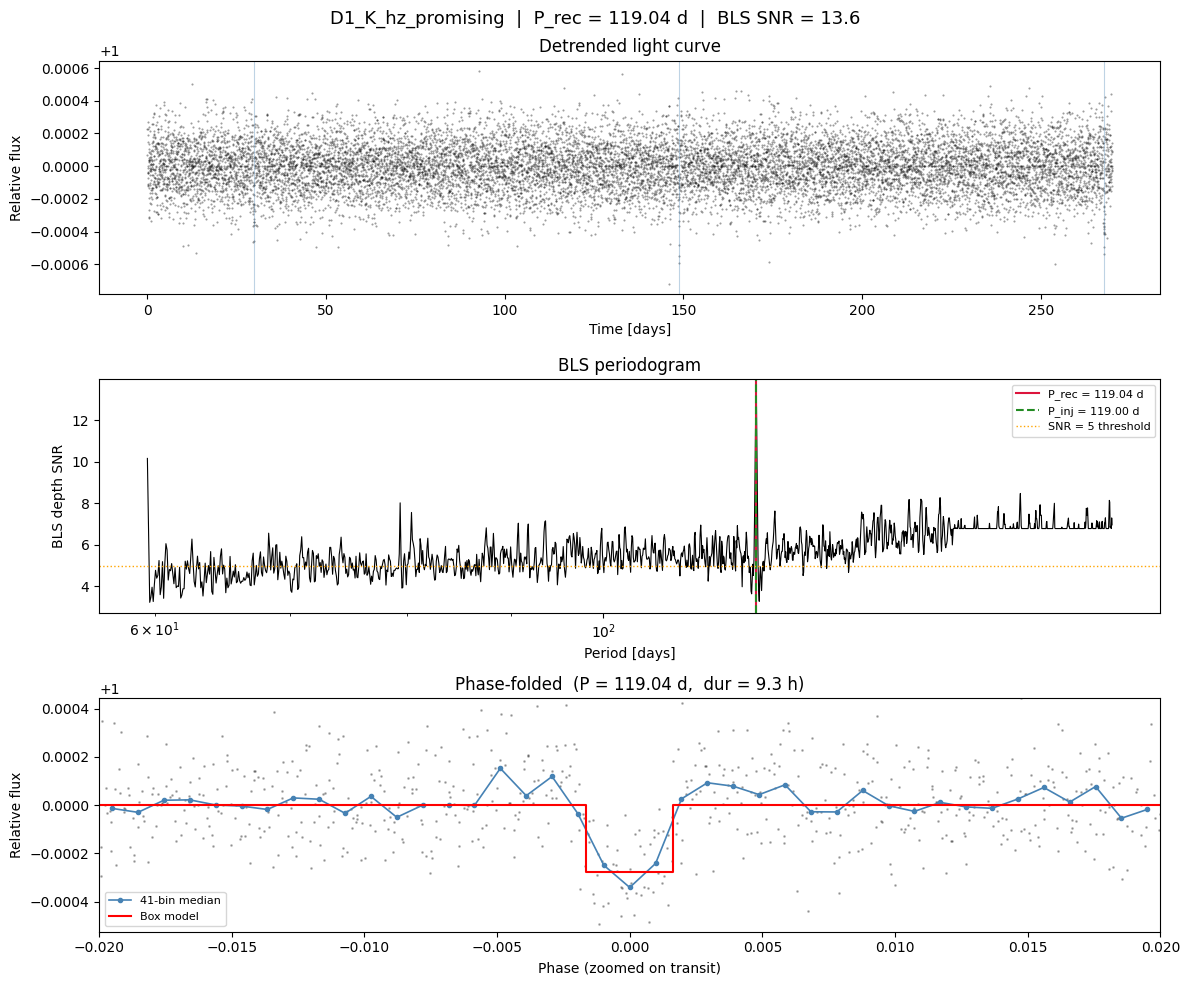

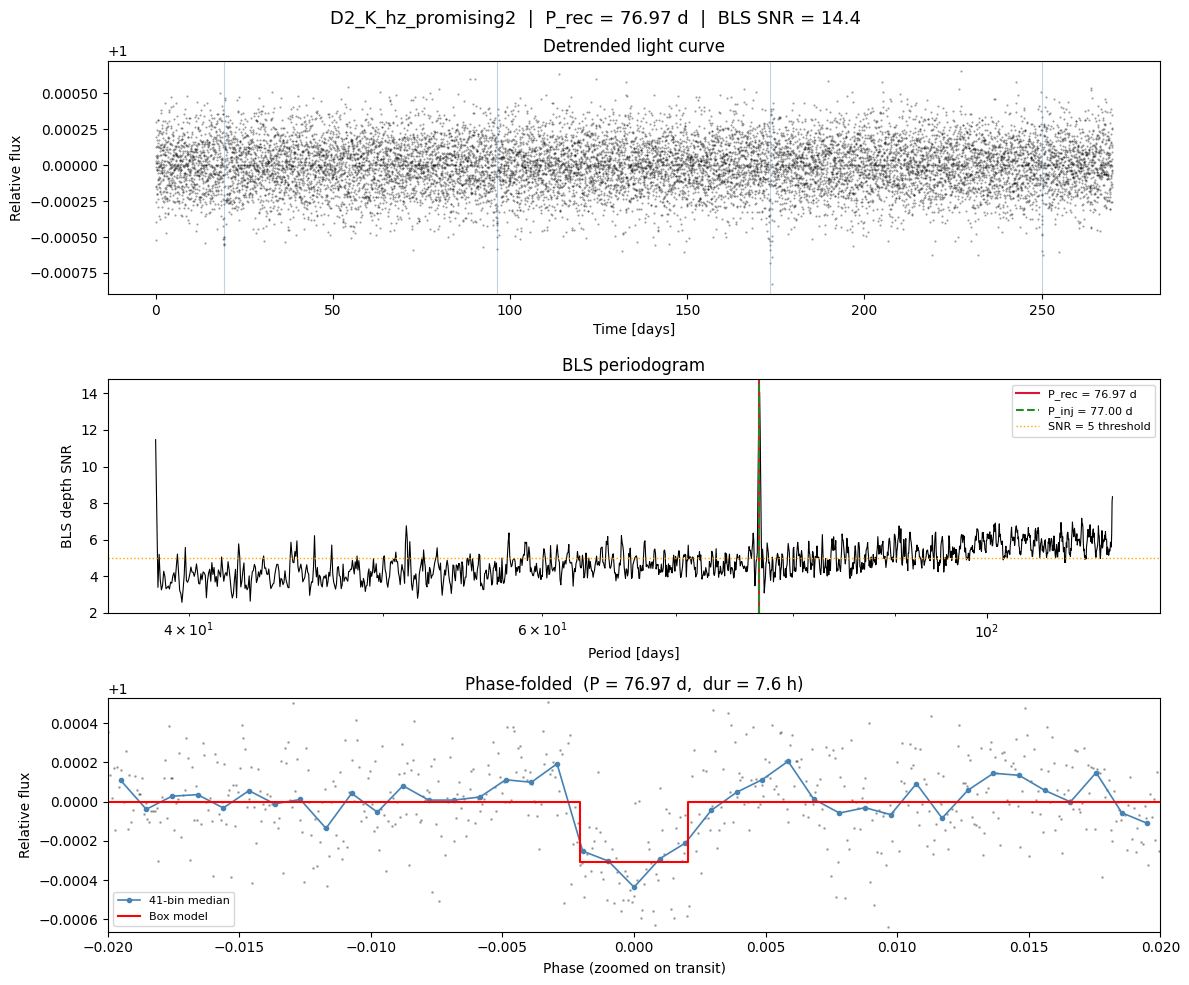

In [34]:
# BLS diagnostic plots — Promising systems (renders from cache or fresh run)
_promising = [r['config'] for r in rows if r['verdict'] == 'Promising']
print(f'Plotting {len(_promising)} Promising system(s): {_promising}')
for _cfg in _promising:
    _time, _flux_raw = lc_store[_cfg]
    _flux_det = detrend_flux(_time, _flux_raw, window_days=DETREND_WIN_D)
    plot_bls_diagnostic(_cfg, _time, _flux_det, bls_results_store[_cfg], truth=SYSTEMS[_cfg])


In [ ]:
#  Detection table

df = pd.DataFrame(rows)

try:

    def color_verdict(val):
        colors = {
            'Promising':     'background-color: #d5f5e3; color: #1a5e36',
            'Marginal':      'background-color: #fdebd0; color: #7e5109',
            'Non-promising': 'background-color: #fadbd8; color: #922b21',
        }
        return colors.get(val, '')

    def color_detected(val):
        if val is True:  return 'background-color: #d5f5e3'
        if val is False: return 'background-color: #fadbd8'
        return ''

    styled = (
        df.style
          .map(color_verdict, subset=['verdict'])
          .map(color_detected, subset=['detected'])
          .format({
              'P_injected_d':     '{:.0f}',
              'P_recovered_d':    '{:.1f}',
              'period_error_pct': '{:.1f}%',
              'depth_ppm':        '{:.1f}',
              'bls_peak_snr':     '{:.4f}',
              'depth_snr':        '{:.2f}',
              'S_earth':          '{:.3f}',
              'Teq_K':            '{:.0f}',
              'rank_score':       '{:.3f}',
          }, na_rep='—')
          .set_caption('Transit Detection Table — PSLS Simulated Systems')
    )
    display(styled)

except (ImportError, AttributeError):
    # jinja2 not available — plain display
    pd.set_option('display.max_columns', None)
    pd.set_option('display.width', 200)
    display(df)

,config,science_case,star_type,P_injected_d,P_recovered_d,period_error_pct,n_transits_expected,depth_ppm,bls_peak_snr,depth_snr,detected,S_earth,Teq_K,in_habitable_zone_flux,in_habitable_zone_teq_band,rank_score,verdict
0,A1_K_hot,Hot inner control,K-dwarf,12,12.0,0.0%,67,203.3,5.5712,7.27,True,30.608,599,False,False,0.465,Marginal
1,A2_K_hz,HZ target,K-dwarf,45,48.5,7.8%,18,164.6,5.4540,3.05,False,5.122,383,False,False,0.451,Non-promising
2,B1_G_hot,Hot inner control,G-dwarf,15,22.0,46.9%,54,127.5,5.2034,2.97,False,68.392,732,False,False,0.545,Non-promising
3,B2_G_hz,HZ target (Earth analog),G-dwarf,365,206.0,43.5%,2,85.3,5.0987,0.38,False,0.985,254,True,True,1.529,Non-promising
4,B3_G_cold,Cold outer control,G-dwarf,730,369.4,49.4%,1,151.7,5.1654,0.48,False,0.385,200,False,True,0.659,Non-promising
5,C1_F_hot,Hot inner control,F-dwarf,20,25.0,25.1%,40,62.3,5.9684,0.53,False,82.994,768,False,False,0.518,Non-promising
6,C2_F_hz,HZ target,F-dwarf,500,256.0,48.8%,1,50.5,6.7723,0.07,False,1.141,263,True,True,1.403,Non-promising
7,C3_F_adversarial,Adversarial (noisy),F-dwarf,500,385.4,22.9%,1,39.9,5.9339,0.05,False,1.141,263,True,True,1.383,Non-promising
8,D1_K_hz_promising,HZ promising (super-Earth),K-dwarf,119,119.0,0.0%,6,983.8,13.5516,16.24,True,1.373,276,False,False,0.739,Promising
9,D2_K_hz_promising2,HZ promising (super-Earth),Late K-dwarf,77,77.0,0.0%,10,1416.6,14.4063,25.28,True,1.369,275,True,False,0.710,Promising


In [36]:

T_SUN  = 5772.0    # K  (solar effective temperature)
R_SUN  = 6.957e8   # m  (solar radius)
AU_M   = 1.496e11  # m  (1 astronomical unit)
ALBEDO = 0.3       # Bond albedo (Earth-like)

deriv_rows = []
for cfg, truth in SYSTEMS.items():
    R  = truth['rstar']   # R_star  [R_sun]
    T  = truth['teff']    # T_star  [K]
    a  = truth['a_au']    # a       [AU]
    R_p = truth['rp_re']    # R_planet [R_earth]

    # Formula 1 — stellar luminosity
    L = R**2 * (T / T_SUN)**4                         # L_star / L_sun

    # Formula 2 — incident stellar flux (Earth units)
    S = L / a**2                                       # S_earth

    # Formula 3 — equilibrium temperature
    R_m   = R * R_SUN                                 # R_star [m]
    a_m   = a * AU_M                                  # a      [m]
    Teq   = T * (R_m / (2 * a_m))**0.5 * (1 - ALBEDO)**0.25   # A=0.3
    Teq0  = T * (R_m / (2 * a_m))**0.5                        # A=0 (upper bound)

    row = df[df['config'] == cfg].iloc[0]
    deriv_rows.append({
        'config':          cfg,
        'star_type':       truth['star_type'],
        'Teff_K':          int(T),
        'Rstar_Rsun':      R,
        'a_AU':            a,
        'L_star_Lsun':     round(L, 4),
        'S_earth':         round(S, 3),
        'R_p':             round(R_p, 3),
        'Teq_K (A=0.3)':   round(Teq, 1),
        'Teq_K (A=0)':     round(Teq0, 1),
        'in_HZ':           row['in_habitable_zone_flux'],
        'verdict':         row['verdict'],
    })

df_deriv = pd.DataFrame(deriv_rows)
print("Habitable Zone Derivation Table")
print(df_deriv.to_string(index=False))


Habitable Zone Derivation Table
            config    star_type  Teff_K  Rstar_Rsun  a_AU  L_star_Lsun  S_earth   R_p  Teq_K (A=0.3)  Teq_K (A=0)  in_HZ       verdict
          A1_K_hot      K-dwarf    4800        0.72 0.090       0.2479   30.608 1.121          598.8        654.7  False      Marginal
           A2_K_hz      K-dwarf    4800        0.72 0.220       0.2479    5.122 1.009          383.0        418.7  False Non-promising
          B1_G_hot      G-dwarf    5750        1.00 0.120       0.9848   68.392 1.233          732.1        800.4  False Non-promising
           B2_G_hz      G-dwarf    5750        1.00 1.000       0.9848    0.985 1.009          253.6        277.3   True Non-promising
         B3_G_cold      G-dwarf    5750        1.00 1.600       0.9848    0.385 1.345          200.5        219.2  False Non-promising
          C1_F_hot      F-dwarf    6300        1.30 0.170       2.3985   82.994 1.121          768.4        840.1  False Non-promising
           C2_F_hz     

[cache] Loaded BLS power spectra for 12 systems


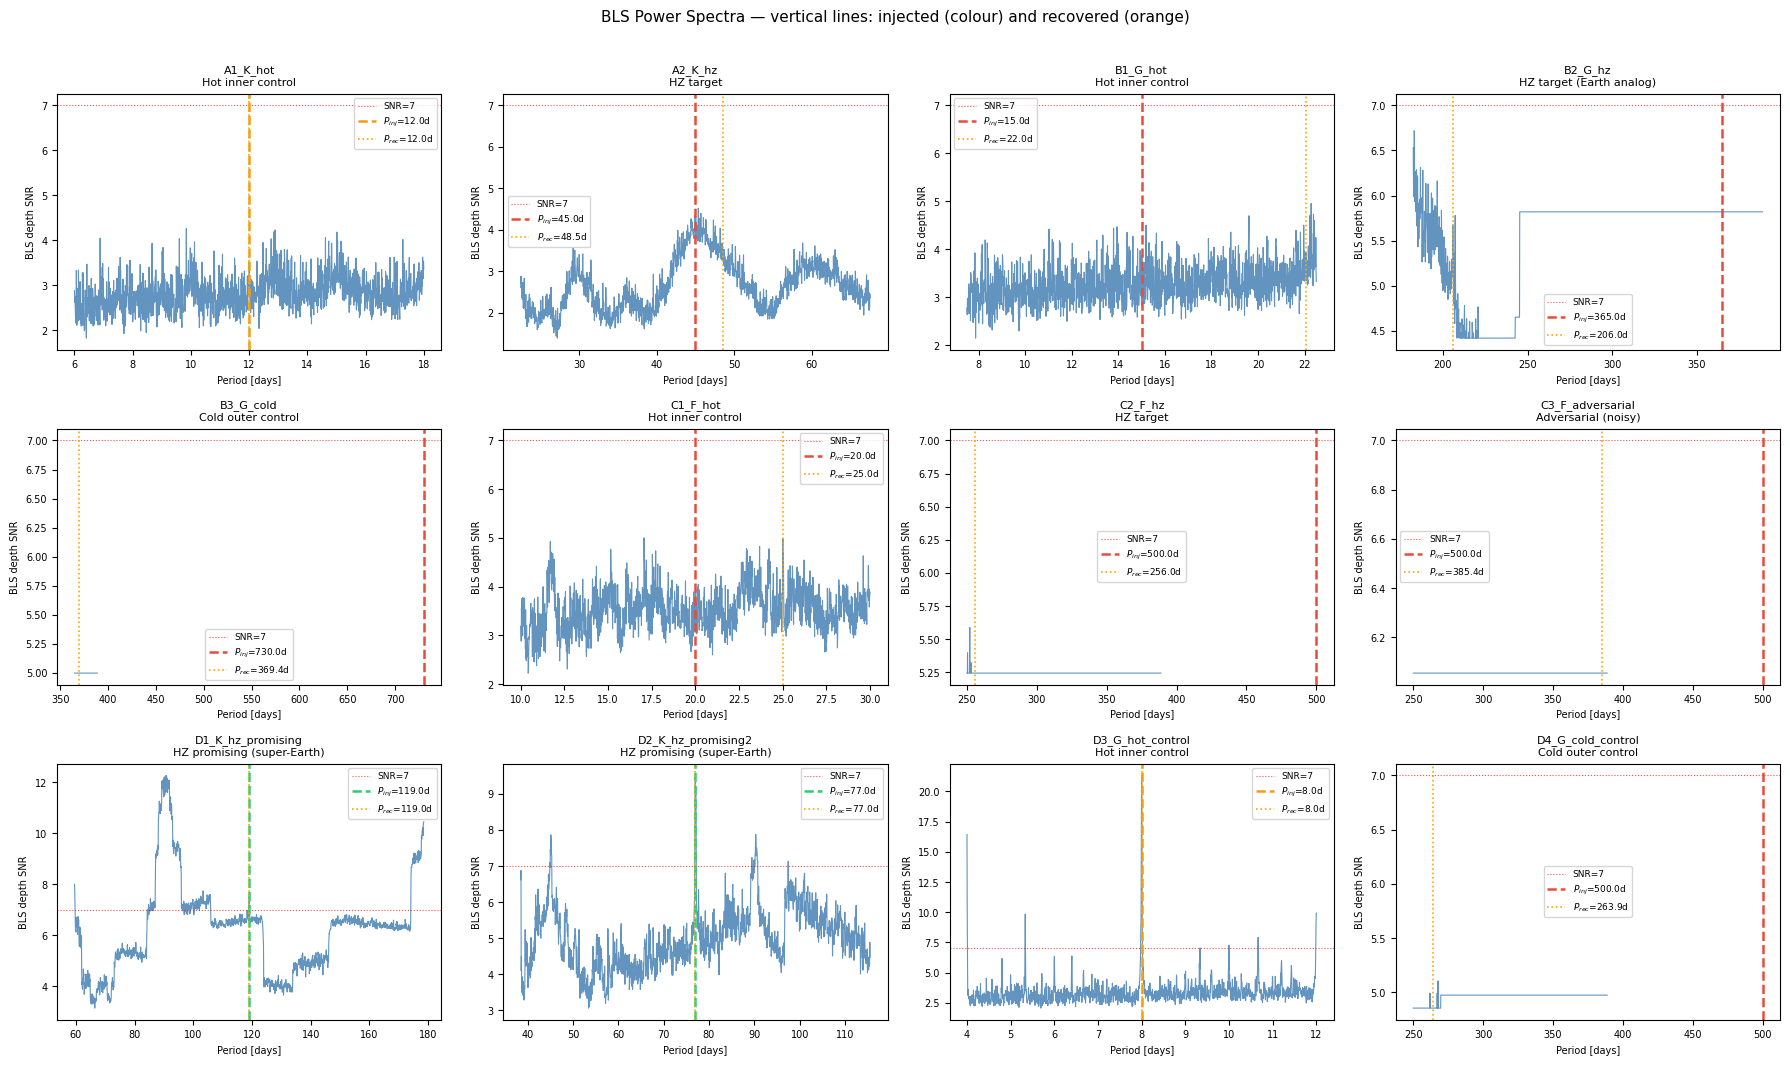

In [ ]:
#  BLS power spectra (3×4 grid for 12 systems) — power curves cached

_cache_spectra = os.path.join(CACHE_DIR, "bls_power_spectra.pkl")

if not FORCE_RERUN and os.path.exists(_cache_spectra):
    with open(_cache_spectra, "rb") as f: power_spectra_store = pickle.load(f)
    print(f"[cache] Loaded BLS power spectra for {len(power_spectra_store)} systems")
else:
    power_spectra_store = {}
    for config, truth in SYSTEMS.items():
        if config not in lc_store:
            continue
        p_inj = truth['p_inj']
        p_min = max(0.5 * p_inj, 1.0)
        p_max = min(1.5 * p_inj, 0.48 * BASELINE_DAYS)
        if p_min >= p_max:
            continue
        time_days, flux = lc_store[config]
        y = flux - np.nanmean(flux)
        noise = float(np.std(y)) or 1.0
        periods = np.linspace(p_min, p_max, 1500)
        dur = float(np.clip(0.05 * (p_inj / 10.0) ** (1/3), 0.02, 0.45))
        bls_obj = BoxLeastSquares(time_days, y, dy=np.full_like(y, noise))
        res = bls_obj.power(periods, dur)
        power_spectra_store[config] = (periods, np.asarray(res.depth_snr))
        print(f'  computed spectrum: {config}')
    with open(_cache_spectra, "wb") as f: pickle.dump(power_spectra_store, f)
    print(f"[cache] Saved BLS power spectra → {CACHE_DIR}")

n_sys = len(SYSTEMS)
ncols = 4
nrows = math.ceil(n_sys / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(18, nrows * 3.5))
axes = axes.flatten()

for idx, (config, truth) in enumerate(SYSTEMS.items()):
    ax = axes[idx]
    p_inj = truth['p_inj']
    row   = df[df['config'] == config].iloc[0]

    if config not in lc_store:
        ax.set_visible(False)
        continue

    if config not in power_spectra_store:
        ax.text(0.5, 0.5, f'P={p_inj}d\nexceeds baseline',
                ha='center', va='center', transform=ax.transAxes, fontsize=9)
        ax.set_title(config, fontsize=9)
        continue

    periods, power = power_spectra_store[config]

    vcolor = VERDICT_COLORS[row['verdict']]
    ax.plot(periods, power, color='steelblue', lw=0.8, alpha=0.85)
    ax.axhline(7.0, color='red', lw=0.8, ls=':', alpha=0.7, label='SNR=7')
    ax.axvline(p_inj, color=vcolor, lw=1.8, ls='--',
               label=f'$P_{{inj}}$={p_inj}d')
    p_rec = row['P_recovered_d']
    if not np.isnan(p_rec):
        ax.axvline(p_rec, color='orange', lw=1.2, ls=':',
                   label=f'$P_{{rec}}$={p_rec:.1f}d')
    ax.set_title(f'{config}\n{row["science_case"]}', fontsize=8)
    ax.set_xlabel('Period [days]', fontsize=7)
    ax.set_ylabel('BLS depth SNR', fontsize=7)
    ax.tick_params(labelsize=7)
    ax.legend(fontsize=6.5)

# Hide any unused axes
for idx in range(n_sys, len(axes)):
    axes[idx].set_visible(False)

fig.suptitle('BLS Power Spectra — vertical lines: injected (colour) and recovered (orange)',
             fontsize=11, y=1.01)
plt.tight_layout()
plt.show()

In [37]:
# Phase-fold each system at BLS-recovered period + t0 — cached

N_BINS = 201

_cache_phase = os.path.join(CACHE_DIR, "phase_folded_store.pkl")

if not FORCE_RERUN and os.path.exists(_cache_phase):
    with open(_cache_phase, "rb") as f: phase_folded_store = pickle.load(f)
    print(f"[cache] Loaded phase-fold for {len(phase_folded_store)} systems")
else:
    phase_folded_store = {}

    for config, (time_days, flux_raw) in lc_store.items():
        rec = bls_results_store.get(config, {})
        p_fold  = rec.get("period_recovered_days", float('nan'))
        t0_fold = float(rec.get("transit_time_days", 0.0))
        flux_det = detrend_flux(time_days, flux_raw, window_days=DETREND_WIN_D)
        if np.isnan(p_fold) or p_fold <= 0:
            phase_folded_store[config] = np.zeros(N_BINS, dtype=np.float32)
        else:
            folded = phase_fold_lightcurve(
                flux_det, time_days, period_days=p_fold, t0_days=t0_fold, n_bins=N_BINS
            )
            phase_folded_store[config] = folded

    with open(_cache_phase, "wb") as f: pickle.dump(phase_folded_store, f)
    print(f"[cache] Saved phase-fold → {CACHE_DIR}")

print(f"Phase-folded {len(phase_folded_store)} systems → {N_BINS} bins each")

[cache] Loaded phase-fold for 12 systems
Phase-folded 12 systems → 201 bins each


Detected systems: ['A1_K_hot', 'D1_K_hz_promising', 'D2_K_hz_promising2', 'D3_G_hot_control']


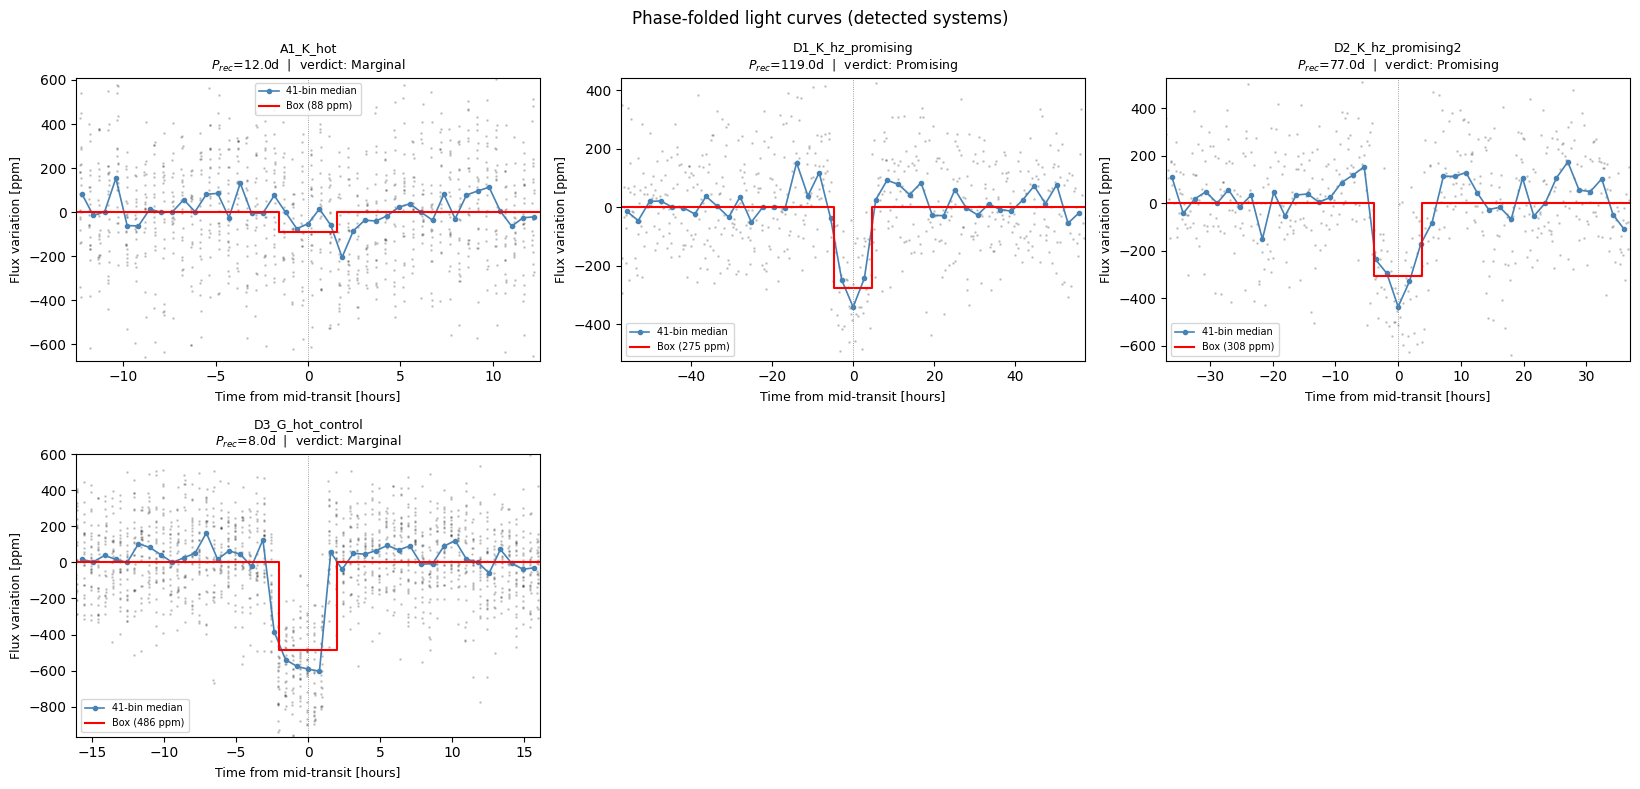

In [86]:
#  Phase-folded light curves for detected systems (zoomed on transit)

detected_configs = df[df['detected'] == True]['config'].tolist()
print(f'Detected systems: {detected_configs}')

if not detected_configs:
    print('No detections — skipping phase-fold plots.')
else:
    ncols = min(len(detected_configs), 3)
    nrows = math.ceil(len(detected_configs) / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(5.5 * ncols, 4 * nrows), squeeze=False)
    axes = axes.flatten()

    for idx, config in enumerate(detected_configs):
        ax = axes[idx]
        time_days, flux_raw = lc_store[config]
        flux = detrend_flux(time_days, flux_raw, window_days=DETREND_WIN_D)  # match pipeline
        row  = df[df['config'] == config].iloc[0]
        p_rec = float(row['P_recovered_d'])
        rec   = bls_results_store.get(config, {})
        t0    = float(rec.get('transit_time_days', time_days[0]))
        dur_d = float(rec.get('duration_recovered_days', 0.0))
        # BLS-recovered depth (matches the detrended fold); the injected depth_ppm is truth
        # and would draw a box deeper than the observed dip for diluted/grazing cases.
        depth = float(rec.get('depth_frac', float(row['depth_ppm']) * 1e-6))

        phase = ((time_days - t0) / p_rec) % 1.0
        phase[phase > 0.5] -= 1.0  # centre on transit

        # Zoom to a few transit-widths and bin finely WITHIN that window (a transit is far
        # narrower than 1/100 of the period, so full-phase bins wash the dip out).
        half_phase = (dur_d / (2.0 * p_rec)) if dur_d > 0 else 0.01
        zoom = float(min(max(8.0 * half_phase, 0.02), 0.5))
        n_bins = 41
        zbins  = np.linspace(-zoom, zoom, n_bins + 1)
        zcent  = 0.5 * (zbins[:-1] + zbins[1:])
        fb = np.full(n_bins, np.nan)
        for b in range(n_bins):
            m = (phase >= zbins[b]) & (phase < zbins[b + 1])
            if m.any():
                fb[b] = np.median(flux[m])

        xh = zcent * p_rec * 24.0            # hours from mid-transit
        ax.plot(phase * p_rec * 24.0, (flux - 1) * 1e6, 'k.', ms=2, alpha=0.15)
        ax.plot(xh, (fb - 1) * 1e6, 'o-', ms=3, lw=1.2, color='steelblue', label=f'{n_bins}-bin median')

        # Box from the BLS-recovered duration + depth
        half_h = half_phase * p_rec * 24.0
        zoom_h = zoom * p_rec * 24.0
        ax.plot([-zoom_h, -half_h, -half_h, half_h, half_h, zoom_h],
                [0, 0, -depth * 1e6, -depth * 1e6, 0, 0],
                'r-', lw=1.5, label=f'Box ({depth*1e6:.0f} ppm)')
        ax.axvline(0, color='gray', lw=0.6, ls=':')

        ax.set_xlim(-zoom_h, zoom_h)
        in_win = np.abs(phase) <= zoom
        yv = (flux[in_win] - 1) * 1e6
        if np.isfinite(yv).any():
            lo = min(float(np.nanpercentile(yv, 2)), -depth * 1e6 * 1.5)
            hi = float(np.nanpercentile(yv, 98))
            pad = 0.15 * (hi - lo + 1e-9)
            ax.set_ylim(lo - pad, hi + pad)

        ax.set_xlabel('Time from mid-transit [hours]', fontsize=9)
        ax.set_ylabel('Flux variation [ppm]', fontsize=9)
        ax.set_title(f'{config}\n$P_{{rec}}$={p_rec:.1f}d  |  verdict: {row["verdict"]}', fontsize=9)
        ax.legend(fontsize=7)

    for j in range(len(detected_configs), len(axes)):
        axes[j].set_visible(False)

    fig.suptitle('Phase-folded light curves (detected systems)', fontsize=12)
    plt.tight_layout()
    plt.show()


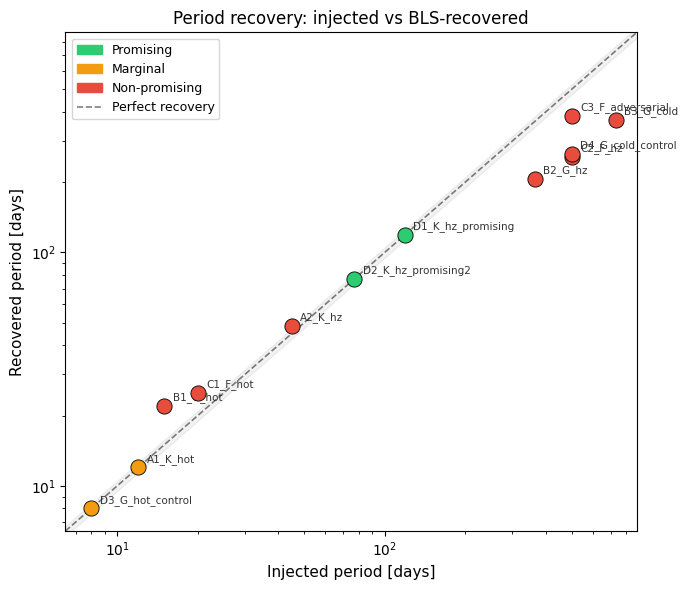

In [39]:
# Period recovery scatter plot

fig, ax = plt.subplots(figsize=(7, 6))

p_inj_vals = df['P_injected_d'].values
p_rec_vals = df['P_recovered_d'].values
verdicts   = df['verdict'].values
configs    = df['config'].values

# Perfect-recovery diagonal
lims = [0.8 * np.nanmin(p_inj_vals), 1.2 * np.nanmax(p_inj_vals)]
ax.plot(lims, lims, 'k--', lw=1.2, alpha=0.5, label='Perfect recovery')
ax.fill_between(lims, [l * 0.95 for l in lims], [l * 1.05 for l in lims],
                color='grey', alpha=0.10, label='±5% tolerance')

for p_i, p_r, v, cfg in zip(p_inj_vals, p_rec_vals, verdicts, configs):
    if np.isnan(p_r):
        continue
    ax.scatter(p_i, p_r, color=VERDICT_COLORS[v], s=120, zorder=5,
               edgecolors='k', linewidths=0.6)
    ax.annotate(cfg, (p_i, p_r), textcoords='offset points',
                xytext=(6, 4), fontsize=7.5, color='#333')

# Legend patches
patches = [mpatches.Patch(color=c, label=v) for v, c in VERDICT_COLORS.items()]
ax.legend(handles=patches + [ax.lines[0]], loc='upper left', fontsize=9)

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Injected period [days]', fontsize=11)
ax.set_ylabel('Recovered period [days]', fontsize=11)
ax.set_title('Period recovery: injected vs BLS-recovered', fontsize=12)
ax.set_xlim(lims)
ax.set_ylim(lims)
plt.tight_layout()
plt.show()

<>:21: SyntaxWarning: invalid escape sequence '\o'
<>:22: SyntaxWarning: invalid escape sequence '\o'
<>:21: SyntaxWarning: invalid escape sequence '\o'
<>:22: SyntaxWarning: invalid escape sequence '\o'
/tmp/ipykernel_408490/788420612.py:21: SyntaxWarning: invalid escape sequence '\o'
  ax.set_xlabel('Incident Flux  $S$ [$S_\oplus$]', fontsize=12)
/tmp/ipykernel_408490/788420612.py:22: SyntaxWarning: invalid escape sequence '\o'
  ax.set_ylabel('Planet Radius  $R_p$ [$R_\oplus$]', fontsize=12)


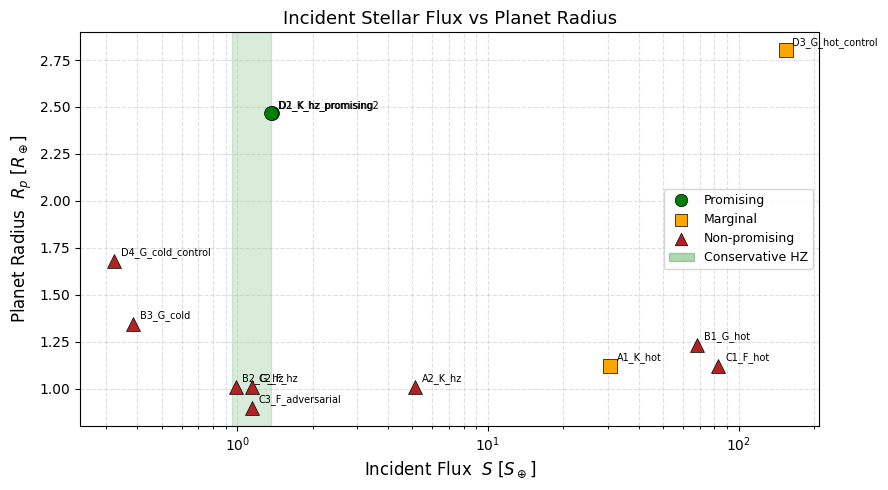

In [40]:
#  Incident Flux (S_earth) vs Planet Radius (Re)
fig, ax = plt.subplots(figsize=(9, 5))

COLORS = {'Promising': 'green', 'Marginal': 'orange', 'Non-promising': 'firebrick'}
MARKERS = {'Promising': 'o', 'Marginal': 's', 'Non-promising': '^'}

for _, r in df_deriv.iterrows():
    row_det = df[df['config'] == r['config']].iloc[0]
    rp_re   = SYSTEMS[r['config']]['rp_re']
    color   = COLORS[r['verdict']]
    marker  = MARKERS[r['verdict']]
    ax.scatter(r['S_earth'], rp_re, color=color, marker=marker,
               s=100, zorder=3, edgecolors='k', linewidths=0.5)
    ax.annotate(r['config'], (r['S_earth'], rp_re),
                textcoords='offset points', xytext=(5, 4), fontsize=7)

# HZ shaded region (conservative Kopparapu: 0.95 ≤ S ≤ 1.37)
ax.axvspan(0.95, 1.37, alpha=0.15, color='green', label='Conservative HZ (0.95–1.37 S⊕)')

ax.set_xscale('log')
ax.set_xlabel('Incident Flux  $S$ [$S_\oplus$]', fontsize=12)
ax.set_ylabel('Planet Radius  $R_p$ [$R_\oplus$]', fontsize=12)
ax.set_title('Incident Stellar Flux vs Planet Radius', fontsize=13)

legend_handles = [
    plt.scatter([], [], color=COLORS[v], marker=MARKERS[v], s=80,
                edgecolors='k', linewidths=0.5, label=v)
    for v in COLORS
]
legend_handles.append(
    plt.matplotlib.patches.Patch(color='green', alpha=0.3, label='Conservative HZ')
)
ax.legend(handles=legend_handles, fontsize=9)
ax.grid(True, which='both', ls='--', alpha=0.4)
plt.tight_layout()
plt.show()


<>:16: SyntaxWarning: invalid escape sequence '\m'
<>:16: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_408490/1450343723.py:16: SyntaxWarning: invalid escape sequence '\m'
  ax.set_xlabel('Equilibrium Temperature  $T_{\mathrm{eq}}$  [K]  (A = 0.3)', fontsize=12)


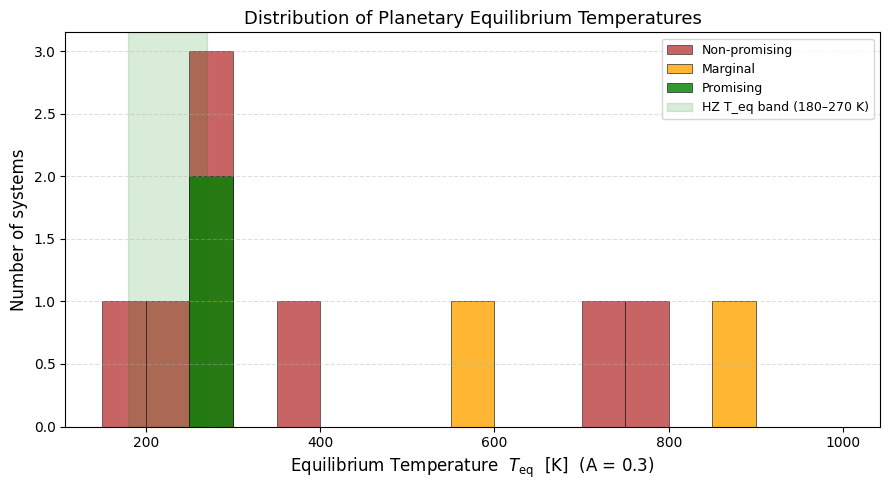

In [41]:
#  Histogram of Equilibrium Temperatures
fig, ax = plt.subplots(figsize=(9, 5))

teq_promising    = [r['Teq_K (A=0.3)'] for _, r in df_deriv.iterrows() if r['verdict'] == 'Promising']
teq_marginal     = [r['Teq_K (A=0.3)'] for _, r in df_deriv.iterrows() if r['verdict'] == 'Marginal']
teq_nonpromising = [r['Teq_K (A=0.3)'] for _, r in df_deriv.iterrows() if r['verdict'] == 'Non-promising']

bins = range(150, 1050, 50)
ax.hist(teq_nonpromising, bins=bins, color='firebrick', alpha=0.7, label='Non-promising', edgecolor='k', linewidth=0.5)
ax.hist(teq_marginal,     bins=bins, color='orange',   alpha=0.8, label='Marginal',      edgecolor='k', linewidth=0.5)
ax.hist(teq_promising,    bins=bins, color='green',    alpha=0.8, label='Promising',      edgecolor='k', linewidth=0.5)

# HZ Teq band (conservative: 180–270 K)
ax.axvspan(180, 270, alpha=0.15, color='green', label='HZ T_eq band (180–270 K)')

ax.set_xlabel('Equilibrium Temperature  $T_{\mathrm{eq}}$  [K]  (A = 0.3)', fontsize=12)
ax.set_ylabel('Number of systems', fontsize=12)
ax.set_title('Distribution of Planetary Equilibrium Temperatures', fontsize=13)
ax.legend(fontsize=9)
ax.grid(axis='y', ls='--', alpha=0.4)
plt.tight_layout()
plt.show()


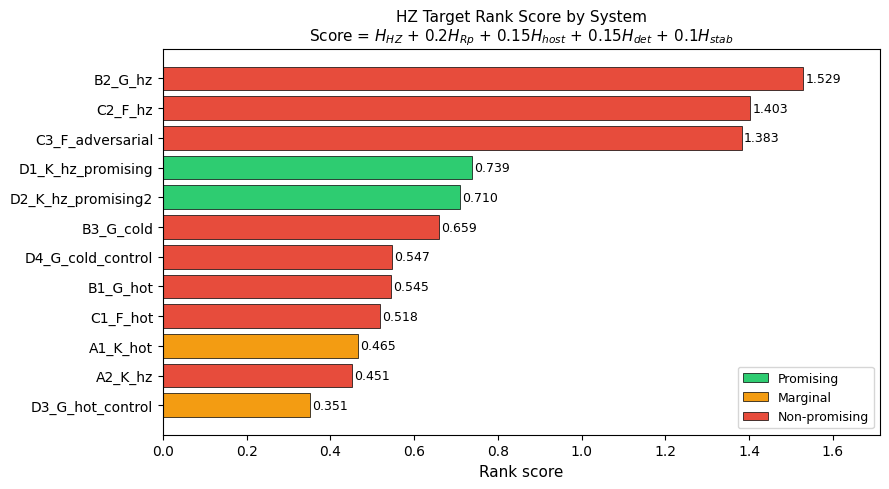

In [42]:
#  Rank score bar chart

df_sorted = df.sort_values('rank_score', ascending=True).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(9, 5))

bar_colors = [VERDICT_COLORS[v] for v in df_sorted['verdict']]
bars = ax.barh(df_sorted['config'], df_sorted['rank_score'],
               color=bar_colors, edgecolor='k', linewidth=0.5)

# Annotate with rank score
for bar, score in zip(bars, df_sorted['rank_score']):
    ax.text(score + 0.005, bar.get_y() + bar.get_height() / 2,
            f'{score:.3f}', va='center', fontsize=9)

# Legend
patches = [mpatches.Patch(color=c, label=v, ec='k', lw=0.5)
           for v, c in VERDICT_COLORS.items()]
ax.legend(handles=patches, loc='lower right', fontsize=9)

ax.set_xlabel('Rank score', fontsize=11)
ax.set_title('HZ Target Rank Score by System\n'
             r'Score = $H_{HZ}$ + 0.2$H_{Rp}$ + 0.15$H_{host}$ + 0.15$H_{det}$ + 0.1$H_{stab}$',
             fontsize=11)
ax.set_xlim(0, df_sorted['rank_score'].max() * 1.12)
plt.tight_layout()
plt.show()

In [43]:
# Cell 10 — Save detection table to CSV

out_path = os.path.join('sim_systems', 'detection_table.csv')
df.to_csv(out_path, index=False)
print(f'Detection table saved to: {os.path.abspath(out_path)}')
print(f'Shape: {df.shape}')
print()
print(df[['config', 'P_injected_d', 'P_recovered_d', 'period_error_pct',
          'depth_snr', 'detected', 'verdict']].to_string(index=False))

Detection table saved to: /home/phuy2808/Astrophysis/MASS/sem_2/Astrobio/sim_systems/detection_table.csv
Shape: (12, 17)

            config  P_injected_d  P_recovered_d  period_error_pct  depth_snr  detected       verdict
          A1_K_hot          12.0          12.00              0.03       7.27      True      Marginal
           A2_K_hz          45.0          48.53              7.84       3.05     False Non-promising
          B1_G_hot          15.0          22.04             46.93       2.97     False Non-promising
           B2_G_hz         365.0         206.03             43.55       0.38     False Non-promising
         B3_G_cold         730.0         369.38             49.40       0.48     False Non-promising
          C1_F_hot          20.0          25.01             25.05       0.53     False Non-promising
           C2_F_hz         500.0         256.02             48.80       0.07     False Non-promising
  C3_F_adversarial         500.0         385.37             22.93     

#  Classic ML: Random Forest 
RF classifier (transit detection) and RF ranker (habitability), with feature
importances and ROC/AUC. 

In [ ]:
# --- Build lookup from YAML configs ---
_T_SUN = 5772.0
_RJ_TO_RE = 11.2089   # 1 Jupiter radius in Earth radii

yaml_data = {}
for config in df["config"]:
    yf = f"sim_systems/{config}.yaml"
    if os.path.exists(yf):
        with open(yf) as f:
            d = yaml.safe_load(f)
        st = d.get("Star", {})
        tr = d.get("Transit", {})
        yaml_data[config] = {
            "Teff_K":    float(st.get("Teff", 5772)),
            "Rp_Rjup":  float(tr.get("PlanetRadius", 0.1)),
            "a_AU":      float(tr.get("PlanetSemiMajorAxis", 1.0)),
        }

# --- Add missing columns ---
df["period_recovered_d"] = df["P_recovered_d"]
# Blind observable: transit count from the BLS-recovered period (not injected truth)
p_rec_arr = df["P_recovered_d"].values
df["n_transits"] = np.where(
    np.isfinite(p_rec_arr) & (p_rec_arr > 0),
    np.maximum(1, (BASELINE_DAYS / np.where(p_rec_arr > 0, p_rec_arr, 1.0)).astype(int)),
    0,
)
df["duration_d"]         = 0.0

Teff_arr   = np.array([yaml_data[c]["Teff_K"]  for c in df["config"]])
Rp_arr     = np.array([yaml_data[c]["Rp_Rjup"] for c in df["config"]]) * _RJ_TO_RE
a_arr      = np.array([yaml_data[c]["a_AU"]    for c in df["config"]])

df["Teff_K"]    = Teff_arr
df["Rp_Rearth"] = Rp_arr

# Rstar back-calculated from: S_earth = Rstar^2 * (Teff/T_sun)^4 / a^2
df["Rstar_Rsun"] = np.sqrt(
    df["S_earth"].values * a_arr**2 / (Teff_arr / _T_SUN)**4
)

# --- Load models and run inference ---
clf, reg = load_models(
    clf_path="models/rf_classifier.pkl",
    reg_path="models/rf_ranker.pkl",
)

X_a = df[FEATURE_COLS_A].values.astype(float)
X_b = df[FEATURE_COLS_B].values.astype(float)

df["transit_prob"]   = predict_transit_prob(clf, X_a)
df["ml_rank_score"]  = predict_rank_score(reg, X_b)
# Detection enters via the H_det slot (weight 0.15) of the transparent rank formula.
# ml_rank_score is trained on labels with snr_proxy=0 (H_det term = 0), so adding
# W_DET*transit_prob reconstructs habitability_rank_score with H_det := transit_prob.
W_DET = 0.15  # H_det weight in habitability_rank_score
df["combined_score"] = df["ml_rank_score"] + W_DET * df["transit_prob"]

print("ML inference complete.")
print(df[["config", "depth_snr", "transit_prob", "ml_rank_score", "combined_score",
          "rank_score"]].sort_values("combined_score", ascending=False).to_string(index=False))

ML inference complete.
            config  depth_snr  transit_prob  ml_rank_score  combined_score  rank_score
           B2_G_hz       0.38         0.695       1.246417        1.350667    1.529314
  C3_F_adversarial       0.05         0.700       1.186121        1.291121    1.382621
           C2_F_hz       0.07         0.680       1.185957        1.287957    1.403357
 D1_K_hz_promising      16.24         0.805       0.700284        0.821034    0.739200
D2_K_hz_promising2      25.28         0.770       0.694377        0.809877    0.710070
         B3_G_cold       0.48         0.710       0.429676        0.536176    0.658723
 D4_G_cold_control       0.96         0.695       0.383045        0.487295    0.546920
          C1_F_hot       0.53         0.505       0.371404        0.447154    0.518094
           A2_K_hz       3.05         0.675       0.342472        0.443722    0.450622
          B1_G_hot       2.97         0.495       0.367082        0.441332    0.544600
          A1_K_hot  

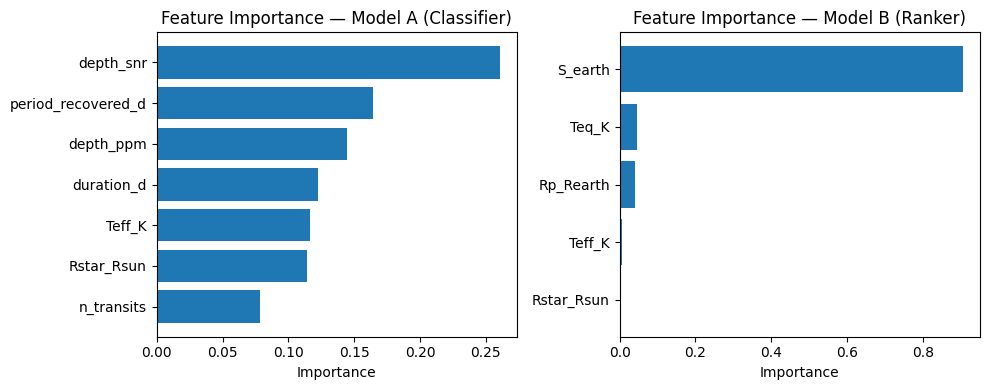

In [45]:
#  feature importance plots

train_df = pd.read_csv("training_data/training_labels.csv")
X_a_all  = train_df[FEATURE_COLS_A].values.astype(float)
y_a_all  = train_df["has_transit"].values
X_b_all  = train_df[FEATURE_COLS_B].values.astype(float)

X_a_tr, X_a_val, y_a_tr, y_a_val = train_test_split(
    X_a_all, y_a_all, test_size=0.2, random_state=42, stratify=y_a_all
)

val_probs = predict_transit_prob(clf, X_a_val)
fpr, tpr, _ = roc_curve(y_a_val, val_probs)
auc = roc_auc_score(y_a_val, val_probs)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Feature importance — Model A
imp_a = clf.feature_importances_
idx_a = np.argsort(imp_a)[::-1]
axes[0].barh([FEATURE_COLS_A[i] for i in idx_a], imp_a[idx_a])
axes[0].set_xlabel("Importance")
axes[0].set_title("Feature Importance — Model A (Classifier)")
axes[0].invert_yaxis()

# Feature importance — Model B
imp_b = reg.feature_importances_
idx_b = np.argsort(imp_b)[::-1]
axes[1].barh([FEATURE_COLS_B[i] for i in idx_b], imp_b[idx_b])
axes[1].set_xlabel("Importance")
axes[1].set_title("Feature Importance — Model B (Ranker)")
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

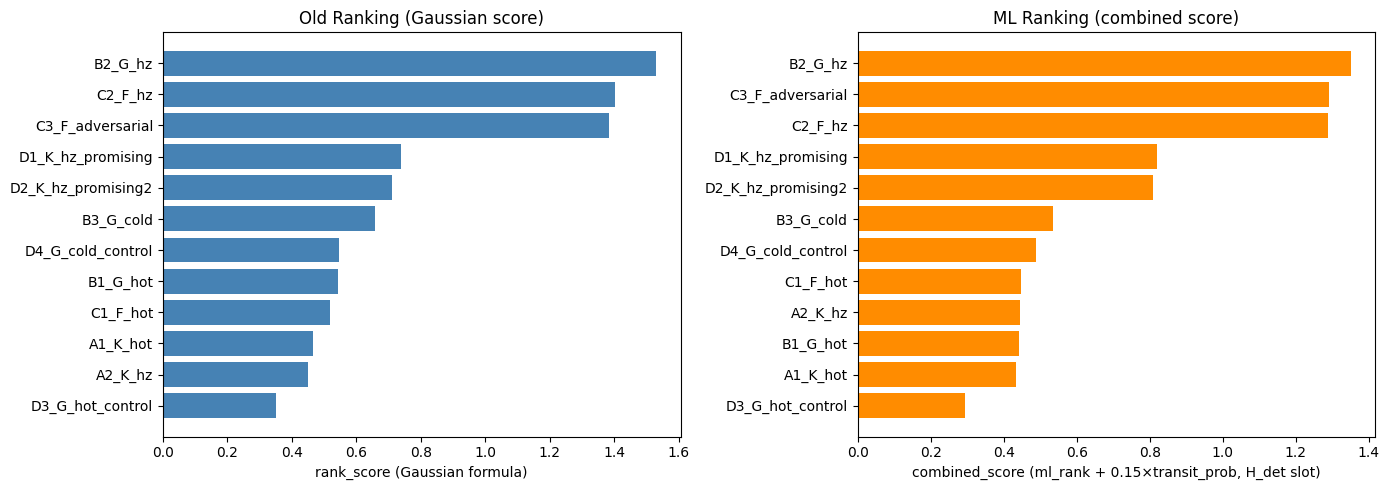

Config                     Old rank   ML rank   Change
-------------------------------------------------------
B2_G_hz                           1         1 =     0
C3_F_adversarial                  3         2 ↑     1
C2_F_hz                           2         3 ↓     1
D1_K_hz_promising                 4         4 =     0
D2_K_hz_promising2                5         5 =     0
B3_G_cold                         6         6 =     0
D4_G_cold_control                 7         7 =     0
C1_F_hot                          9         8 ↑     1
A2_K_hz                          11         9 ↑     2
B1_G_hot                          8        10 ↓     2
A1_K_hot                         10        11 ↓     1
D3_G_hot_control                 12        12 =     0


In [46]:
#  Old Gaussian score vs ML combined_score comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

old_sorted = df.sort_values("rank_score", ascending=False)
axes[0].barh(old_sorted["config"], old_sorted["rank_score"], color="steelblue")
axes[0].set_xlabel("rank_score (Gaussian formula)")
axes[0].set_title("Old Ranking (Gaussian score)")
axes[0].invert_yaxis()

ml_sorted = df.sort_values("combined_score", ascending=False)
axes[1].barh(ml_sorted["config"], ml_sorted["combined_score"], color="darkorange")
axes[1].set_xlabel("combined_score (ml_rank + 0.15×transit_prob, H_det slot)")
axes[1].set_title("ML Ranking (combined score)")
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

old_ranks = {row["config"]: i+1 for i, row in old_sorted.reset_index().iterrows()}
ml_ranks  = {row["config"]: i+1 for i, row in ml_sorted.reset_index().iterrows()}
print(f"{'Config':<25} {'Old rank':>9} {'ML rank':>9} {'Change':>8}")
print("-" * 55)
for cfg in ml_sorted["config"]:
    change = old_ranks[cfg] - ml_ranks[cfg]
    arrow  = "↑" if change > 0 else ("↓" if change < 0 else "=")
    print(f"{cfg:<25} {old_ranks[cfg]:>9} {ml_ranks[cfg]:>9} {arrow}{abs(change):>6}")

[cache] Loaded PSLS heatmap prob_map (10, 10)


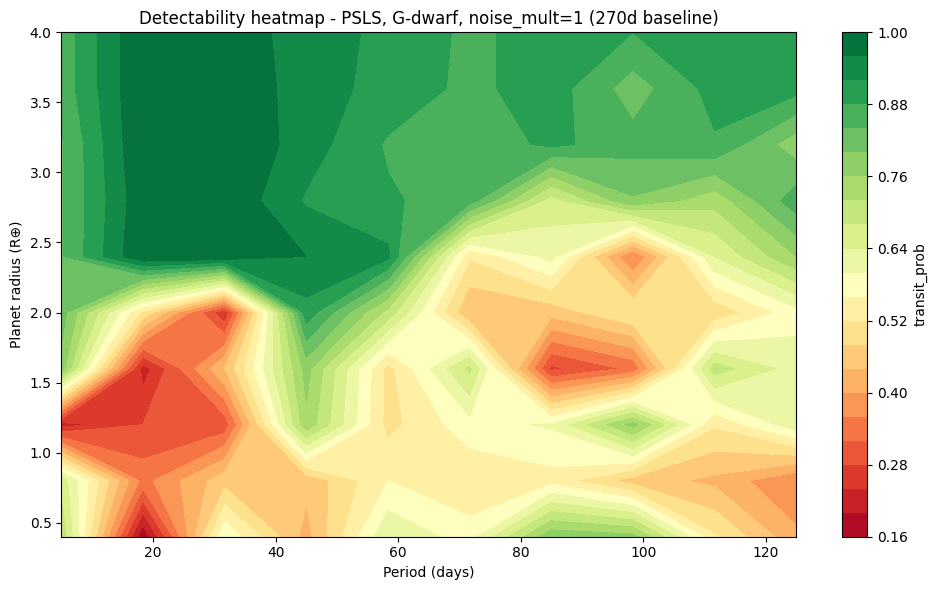

In [ ]:
#  transit_prob detectability heatmap 
# Data generated by sim_systems/run_psls_heatmap.py: 10x10 (period x Rp) grid of PSLS
# simulations on a fixed G-dwarf (Teff 5750, 270d baseline), each recovered with BLS and
# scored by the trained RF classifier (Model A).
# Regenerate:  python3 sim_systems/run_psls_heatmap.py
periods_grid = np.linspace(5.0, 125.0, 10)
rp_grid      = np.linspace(0.4, 4.0, 10)

_cache_heatmap = os.path.join(CACHE_DIR, "heatmap_prob_map.npz")
if not os.path.exists(_cache_heatmap):
    raise FileNotFoundError(
        f"{_cache_heatmap} missing - run:  python3 sim_systems/run_psls_heatmap.py"
    )
_hm = np.load(_cache_heatmap)
assert (np.array_equal(_hm["periods_grid"], periods_grid)
        and np.array_equal(_hm["rp_grid"], rp_grid)), \
    "cached grid mismatch - rerun sim_systems/run_psls_heatmap.py"
prob_map = _hm["prob_map"]
print(f"[cache] Loaded PSLS heatmap prob_map {prob_map.shape}")

fig, ax = plt.subplots(figsize=(10, 6))
im = ax.contourf(periods_grid, rp_grid, prob_map, levels=20, cmap="RdYlGn")
plt.colorbar(im, ax=ax, label="transit_prob")
ax.set_xlabel("Period (days)")
ax.set_ylabel("Planet radius (R\u2295)")
ax.set_title("Detectability heatmap - PSLS, G-dwarf, noise_mult=1 (270d baseline)")
plt.tight_layout()
plt.show()


# Deep Learning: CNN + MLP 
1D-CNN transit classifier on phase-folded light curves and an MLP habitability
ranker, with quantitative evaluation (ROC, confusion matrix, regression diagnostics).

In [ ]:
# Cell CNN-1 — Load CNN/MLP models and run inference

cnn_clf, mlp_ranker, mlp_scaler = load_cnn_models(
    cnn_path="models/cnn_classifier.pt",
    mlp_path="models/mlp_ranker.pt",
    scaler_path="models/mlp_scaler.pkl",
)

# Stack phase-folded arrays (one row per system, in df order)
configs_ordered = df["config"].tolist()
X_cnn = np.stack([phase_folded_store[c] for c in configs_ordered]).astype(np.float32)

# MLP features — need period_d, a_AU, bond_albedo not in df yet
df["period_d"]    = df["P_injected_d"]
df["a_AU"]        = np.array([yaml_data[c]["a_AU"] for c in configs_ordered])
df["bond_albedo"] = 0.3  # default; not directly observable

X_mlp = df[FEATURE_COLS_B_MLP].values.astype(np.float32)
X_mlp_scaled = mlp_scaler.transform(X_mlp)

df["cnn_transit_prob"] = predict_transit_prob_cnn(cnn_clf, X_cnn)
df["mlp_rank_score"]   = predict_rank_score_mlp(mlp_ranker, X_mlp_scaled)
# H_det slot (mirror RF cell-019): mlp_rank_score has H_det=0 (snr_proxy=0 label), so
# adding W_DET*cnn_transit_prob reconstructs the rank formula with H_det := cnn_transit_prob.
W_DET = 0.15
df["cnn_combined"]     = df["mlp_rank_score"] + W_DET * df["cnn_transit_prob"]

print("CNN/MLP inference complete.")
print(df[["config", "cnn_transit_prob", "transit_prob", "mlp_rank_score", "ml_rank_score", "cnn_combined", "combined_score"]]
      .sort_values("cnn_combined", ascending=False).to_string(index=False))

CNN/MLP inference complete.
            config  cnn_transit_prob  transit_prob  mlp_rank_score  ml_rank_score  cnn_combined  combined_score
  C3_F_adversarial          0.810363         0.700        1.322544       1.186121      1.444099        1.291121
           B2_G_hz          0.500057         0.695        1.307336       1.246417      1.382345        1.350667
           C2_F_hz          0.325838         0.680        1.313128       1.185957      1.362003        1.287957
 D4_G_cold_control          0.402313         0.695        0.763288       0.383045      0.823635        0.487295
         B3_G_cold          0.417388         0.710        0.539618       0.429676      0.602226        0.536176
 D1_K_hz_promising          0.999589         0.805        0.276222       0.700284      0.426160        0.821034
          C1_F_hot          0.726088         0.505        0.287106       0.371404      0.396019        0.447154
D2_K_hz_promising2          0.999932         0.770        0.207217       0.6

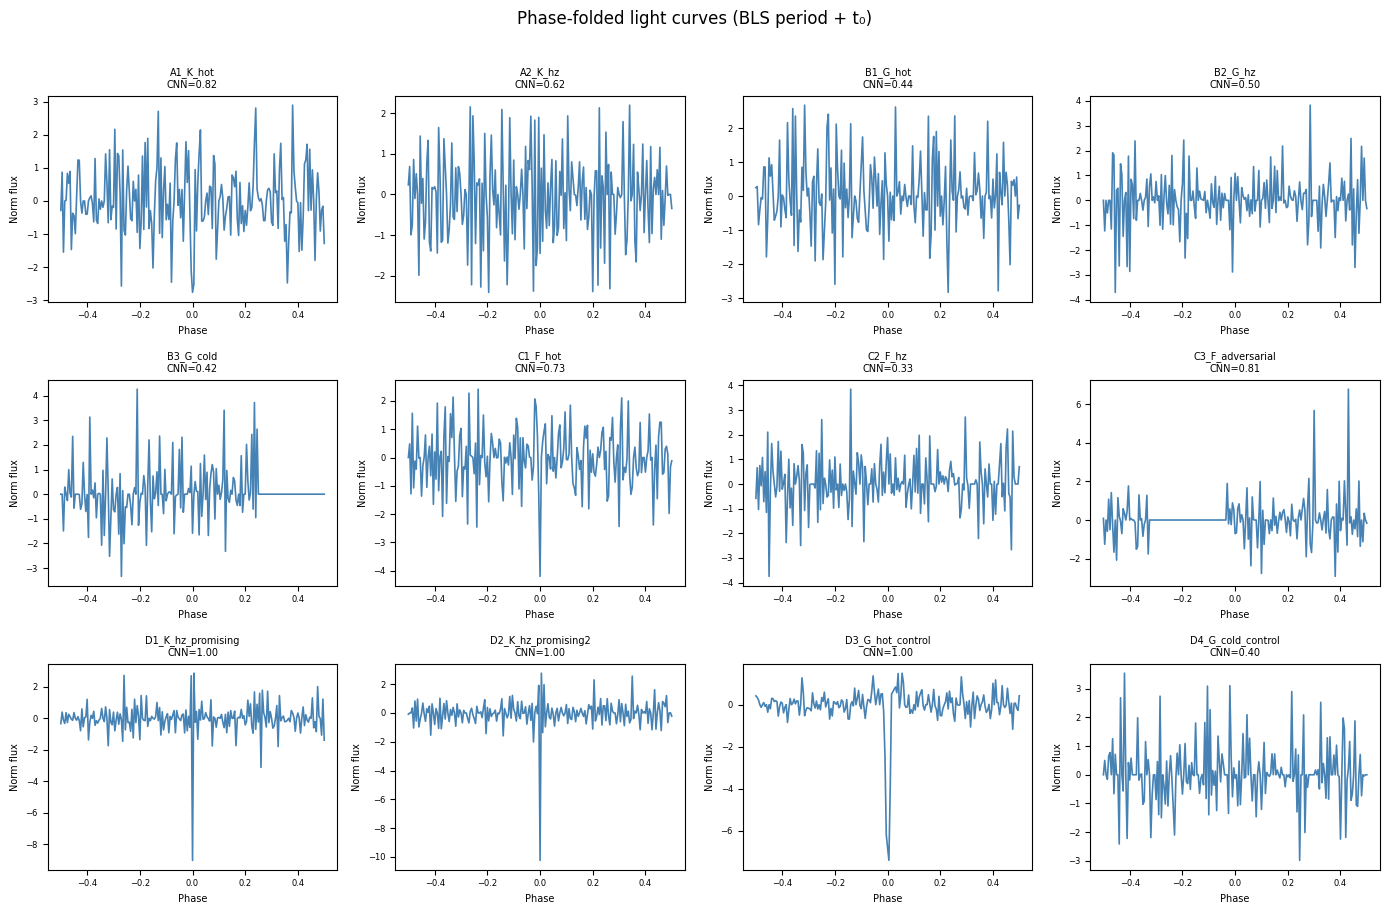

In [50]:
# Cell CNN-3 — Phase-folded LC grid for all systems
configs = list(phase_folded_store.keys())
n = len(configs)
ncols = 4
nrows = (n + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(14, 3 * nrows))
axes = np.array(axes).flatten()

phase_bins = np.linspace(-0.5, 0.5, N_BINS)

for i, config in enumerate(configs):
    folded = phase_folded_store[config]
    ax = axes[i]
    ax.plot(phase_bins, folded, lw=1.2, color="steelblue")
    row = df.loc[df["config"] == config]
    cnn_p = row["cnn_transit_prob"].values[0] if len(row) else float('nan')
    ax.set_title(f"{config}\nCNN={cnn_p:.2f}", fontsize=7)
    ax.set_xlabel("Phase", fontsize=7)
    ax.set_ylabel("Norm flux", fontsize=7)
    ax.tick_params(labelsize=6)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Phase-folded light curves (BLS period + t₀)", fontsize=12, y=1.01)
plt.tight_layout()
plt.show()


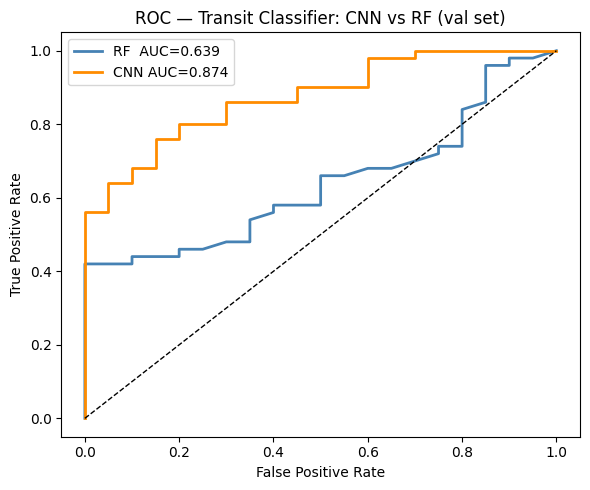

RF AUC=0.6385  CNN AUC=0.8740


In [ ]:
# Receiver Operating Characteristic (ROC) curve: CNN vs RF (training validation set)

train_df = pd.read_csv("training_data/training_labels.csv")
# Classifier + CNN are trained on the NON-cold 350 (cold planets are undetectable noise
# labelled has_transit=1). Evaluate on the same population so the matrix/ROC are honest.
_det_mask = (train_df["tier"] != "cold").to_numpy() if "tier" in train_df.columns else np.ones(len(train_df), bool)
train_df = train_df[_det_mask].reset_index(drop=True)
X_a_all = train_df[FEATURE_COLS_A].values.astype(float)
y_all   = train_df["has_transit"].values
_, X_a_val, _, y_rf_val = train_test_split(X_a_all, y_all, test_size=0.2, random_state=42, stratify=y_all)

rf_probs = predict_transit_prob(clf, X_a_val)
fpr_rf, tpr_rf, _ = roc_curve(y_rf_val, rf_probs)
auc_rf = roc_auc_score(y_rf_val, rf_probs)

X_cnn_all = np.load("training_data/cnn_phase_folded.npy")[_det_mask]
y_cnn_all = np.load("training_data/cnn_labels.npy")[_det_mask]
_, X_cnn_val, _, y_cnn_val = train_test_split(X_cnn_all, y_cnn_all, test_size=0.2, random_state=42, stratify=y_cnn_all)
cnn_probs_val = predict_transit_prob_cnn(cnn_clf, X_cnn_val)
fpr_cnn, tpr_cnn, _ = roc_curve(y_cnn_val, cnn_probs_val)
auc_cnn = roc_auc_score(y_cnn_val, cnn_probs_val)

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(fpr_rf,  tpr_rf,  lw=2, label=f"RF  AUC={auc_rf:.3f}",  color="steelblue")
ax.plot(fpr_cnn, tpr_cnn, lw=2, label=f"CNN AUC={auc_cnn:.3f}", color="darkorange")
ax.plot([0, 1], [0, 1], "k--", lw=1)
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC — Transit Classifier: CNN vs RF (val set)")
ax.legend()
plt.tight_layout()
plt.show()
print(f"RF AUC={auc_rf:.4f}  CNN AUC={auc_cnn:.4f}")

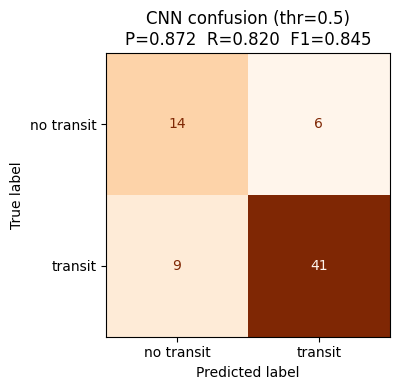

CNN  precision=0.872  recall=0.820  f1=0.845


In [ ]:
#  CNN confusion matrix + precision/recall/F1 (val set)

THRESH = 0.5  # tunable decision threshold
cnn_val_preds = (cnn_probs_val >= THRESH).astype(int)   # cnn_probs_val from Cell CNN-4
cm = confusion_matrix(y_cnn_val, cnn_val_preds)
p  = precision_score(y_cnn_val, cnn_val_preds, zero_division=0)
r  = recall_score(y_cnn_val, cnn_val_preds, zero_division=0)
f1 = f1_score(y_cnn_val, cnn_val_preds, zero_division=0)

fig, ax = plt.subplots(figsize=(4.5, 4))
ConfusionMatrixDisplay(cm, display_labels=["no transit", "transit"]).plot(ax=ax, colorbar=False, cmap="Oranges")
ax.set_title(f"CNN confusion (thr={THRESH})\nP={p:.3f}  R={r:.3f}  F1={f1:.3f}")
plt.tight_layout()
plt.show()
print(f"CNN  precision={p:.3f}  recall={r:.3f}  f1={f1:.3f}")

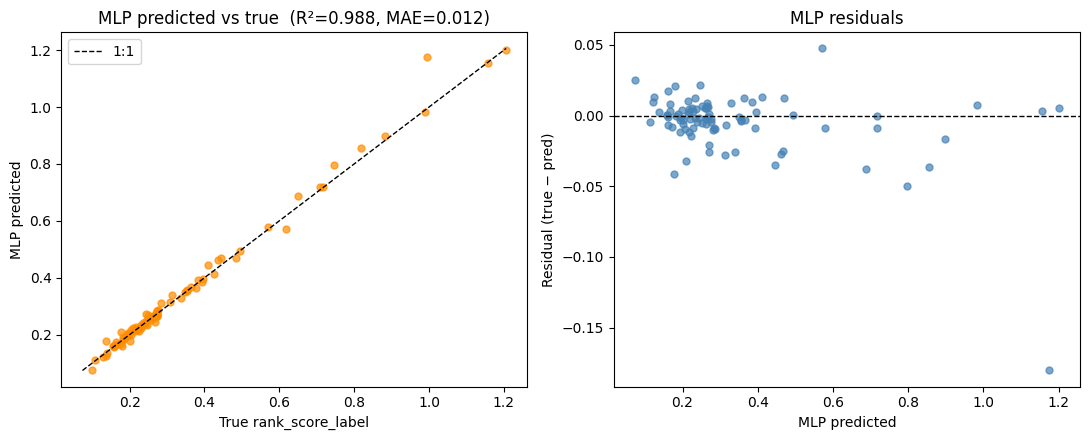

MLP ranker:  R²=0.988  MAE=0.0124  (n_val=90)


In [ ]:
#  MLP ranker regression diagnostics (val set)

# Reproduce the exact MLP train/val split (scaler fit on full X, rng(42) permutation, first 20% = val)
_mlp_df = pd.read_csv("training_data/training_labels.csv")
_Xmlp = _mlp_df[FEATURE_COLS_B_MLP].values.astype(np.float32)
_ymlp = _mlp_df["rank_score_label"].values.astype(np.float32)
_Xmlp_scaled = mlp_scaler.transform(_Xmlp).astype(np.float32)   # mlp_scaler from Cell CNN-1
_order = np.random.default_rng(42).permutation(len(_Xmlp_scaled))
_Xs, _ys = _Xmlp_scaled[_order], _ymlp[_order]
_nval = int(len(_Xs) * 0.2)
_Xval, _yval = _Xs[:_nval], _ys[:_nval]

_preds = predict_rank_score_mlp(mlp_ranker, _Xval)   # mlp_ranker from Cell CNN-1
_resid = _yval - _preds
_r2 = r2_score(_yval, _preds)
_mae = mean_absolute_error(_yval, _preds)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
lims = [min(_yval.min(), _preds.min()), max(_yval.max(), _preds.max())]
axes[0].scatter(_yval, _preds, s=25, alpha=0.7, color="darkorange")
axes[0].plot(lims, lims, "k--", lw=1, label="1:1")
axes[0].set_xlabel("True rank_score_label")
axes[0].set_ylabel("MLP predicted")
axes[0].set_title(f"MLP predicted vs true  (R\u00b2={_r2:.3f}, MAE={_mae:.3f})")
axes[0].legend()

axes[1].scatter(_preds, _resid, s=25, alpha=0.7, color="steelblue")
axes[1].axhline(0, color="k", lw=1, ls="--")
axes[1].set_xlabel("MLP predicted")
axes[1].set_ylabel("Residual (true \u2212 pred)")
axes[1].set_title("MLP residuals")
plt.tight_layout()
plt.show()
print(f"MLP ranker:  R\u00b2={_r2:.3f}  MAE={_mae:.4f}  (n_val={_nval})")

#  Cross-Method Comparison 
Do the data-driven methods reproduce the transparent physics ranking, and where
do they disagree? 

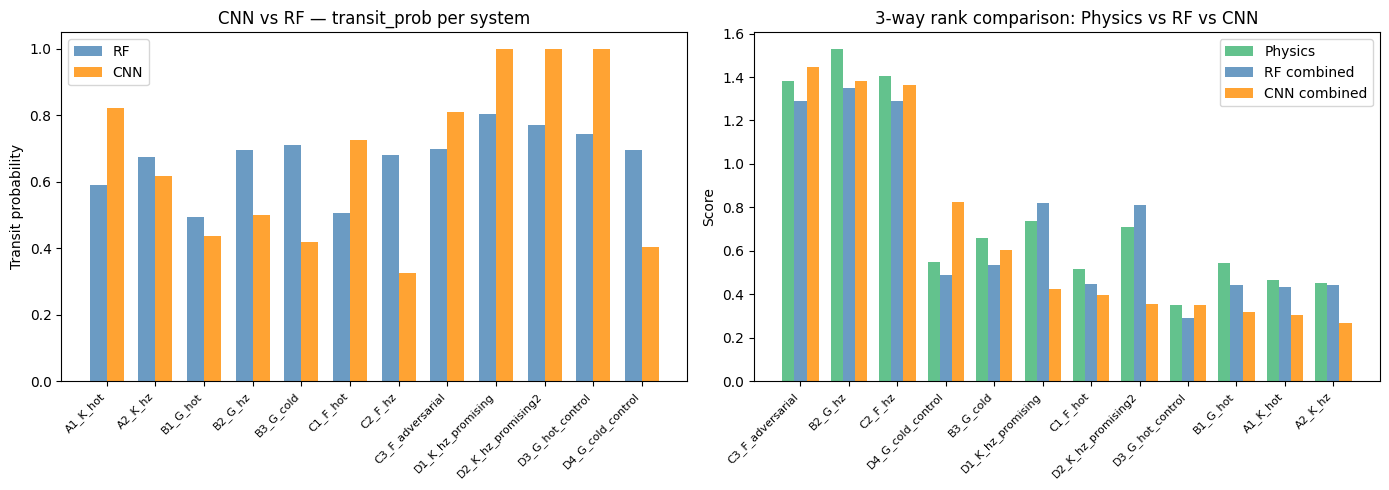

In [ ]:
# CNN vs RF transit_prob + 3-way rank comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

x = np.arange(len(df))
w = 0.35
axes[0].bar(x - w/2, df["transit_prob"],     w, label="RF",  color="steelblue",   alpha=0.8)
axes[0].bar(x + w/2, df["cnn_transit_prob"], w, label="CNN", color="darkorange",  alpha=0.8)
axes[0].set_xticks(x)
axes[0].set_xticklabels(df["config"], rotation=45, ha="right", fontsize=8)
axes[0].set_ylabel("Transit probability")
axes[0].set_title("CNN vs RF — transit_prob per system")
axes[0].legend()

df_r = df.sort_values("cnn_combined", ascending=False)
x2 = np.arange(len(df_r))
w2 = 0.25
axes[1].bar(x2 - w2, df_r["rank_score"],    w2, label="Physics",     color="mediumseagreen", alpha=0.8)
axes[1].bar(x2,      df_r["combined_score"], w2, label="RF combined", color="steelblue",      alpha=0.8)
axes[1].bar(x2 + w2, df_r["cnn_combined"],   w2, label="CNN combined",color="darkorange",     alpha=0.8)
axes[1].set_xticks(x2)
axes[1].set_xticklabels(df_r["config"], rotation=45, ha="right", fontsize=8)
axes[1].set_ylabel("Score")
axes[1].set_title("3-way rank comparison: Physics vs RF vs CNN")
axes[1].legend()

plt.tight_layout()
plt.show()


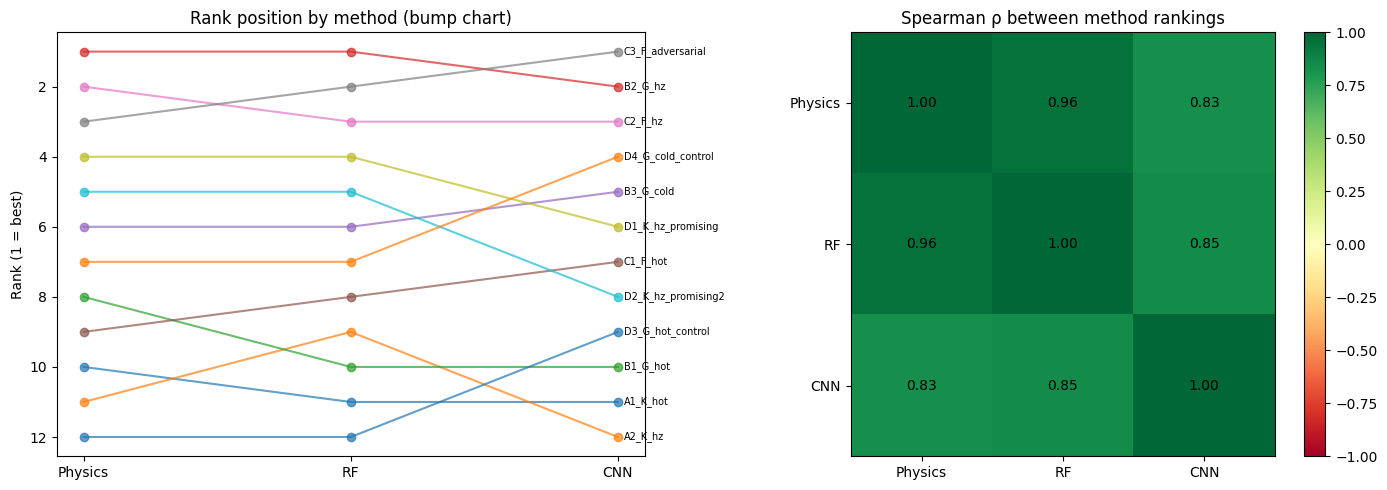

Spearman ρ:
 [[1.    0.958 0.832]
 [0.958 1.    0.846]
 [0.832 0.846 1.   ]]
Kendall τ:
 [[1.    0.879 0.636]
 [0.879 1.    0.636]
 [0.636 0.636 1.   ]]

Systems where methods most disagree (max rank delta):
A2_K_hz               3.0
D2_K_hz_promising2    3.0
D3_G_hot_control      3.0
D4_G_cold_control     3.0
B1_G_hot              2.0


In [ ]:
#  3-method rank comparison: Physics vs RF vs CNN

methods = {"Physics": "rank_score", "RF": "combined_score", "CNN": "cnn_combined"}
names = list(methods)
ranks = pd.DataFrame(
    {m: df[c].rank(ascending=False, method="min").values for m, c in methods.items()},
    index=df["config"].values,
)
sp = np.array([[spearmanr(df[methods[a]], df[methods[b]]).correlation for b in names] for a in names])
kt = np.array([[kendalltau(df[methods[a]], df[methods[b]]).correlation for b in names] for a in names])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bump chart: rank position of each system across the three methods
xpos = np.arange(len(names))
for cfg in ranks.index:
    axes[0].plot(xpos, ranks.loc[cfg].values, "o-", alpha=0.7)
    axes[0].annotate(cfg, (xpos[-1], ranks.loc[cfg].values[-1]), fontsize=7,
                     xytext=(4, 0), textcoords="offset points", va="center")
axes[0].set_xticks(xpos); axes[0].set_xticklabels(names)
axes[0].invert_yaxis()  # rank 1 = best on top
axes[0].set_ylabel("Rank (1 = best)")
axes[0].set_title("Rank position by method (bump chart)")

# Spearman correlation heatmap
im = axes[1].imshow(sp, vmin=-1, vmax=1, cmap="RdYlGn")
axes[1].set_xticks(xpos); axes[1].set_xticklabels(names)
axes[1].set_yticks(xpos); axes[1].set_yticklabels(names)
for i in range(3):
    for j in range(3):
        axes[1].text(j, i, f"{sp[i, j]:.2f}", ha="center", va="center", fontsize=10)
axes[1].set_title("Spearman ρ between method rankings")
fig.colorbar(im, ax=axes[1], fraction=0.046)
plt.tight_layout()
plt.show()

disagree = (ranks.max(axis=1) - ranks.min(axis=1)).sort_values(ascending=False)
print("Spearman ρ:\n", np.round(sp, 3))
print("Kendall τ:\n", np.round(kt, 3))
print("\nSystems where methods most disagree (max rank delta):")
print(disagree.head().to_string())